In [1]:
import sys, os
from importlib.metadata import version as distribution_version

# Installing a different NumPy build into a process that already imported NumPy
# leaves a mixed in-memory state. Detect it and request one clean restart instead
# of continuing to an opaque `_NoValueType` reduction error.
loaded_numpy_version = getattr(sys.modules.get("numpy"), "__version__", None)
from pathlib import Path

# Colab-specific setup
if 'google.colab' in sys.modules:
    if not os.path.exists("ioer-conference-2026-haclathon"):
        !git clone -q https://github.com/ioer-dresden/ioer-conference-2026-haclathon.git
    %cd -q ioer-conference-2026-haclathon/notebooks

# Universal package install
pyexec = sys.executable
!"{pyexec}" -m pip install -q "numpy<2.4"
!../py/modules/pkginstall.sh "{pyexec}" geopandas matplotlib datashader pygal dotenv pygeohash libpysal contextily duckdb mapclassify adjustText cartopy geoviews dask h3 libpysal esda pyarrow lonboard

installed_numpy_version = distribution_version("numpy")
if loaded_numpy_version and loaded_numpy_version != installed_numpy_version:
    raise RuntimeError(
        f"NumPy changed from {loaded_numpy_version} to {installed_numpy_version} "
        "while this kernel was running. Restart the kernel, then Run All once."
    )


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
geopandas already installed (version 1.1.4).
matplotlib already installed (version 3.11.1).
datashader already installed (version 0.19.1).
pygal already installed (version 3.1.3).
dotenv already installed (version 1.2.3).
pygeohash already installed (version 3.5.1).
libpysal already installed (version 4.14.1).
contextily already installed (version 1.7.1).
duckdb already installed (version 1.5.5).
mapclassify already installed (version 2.10.0).
adjustText already installed (version 1.4.0).
cartopy already installed (version 0.25.0).
geoviews already installed (version 1.15.1).
dask already installed (version 2026.8.0).
h3 already installed (version 4.5.0).
libpysal already installed (version 4.14.1).
esda already installed (version 2.9.0).
pyarrow already installed (version 25.0.1).
lonboard already installed (version 0.16.0).


# Digital Landscape Traces: Mapping International-Origin Post Composition in Germany

* **Authors**: Alexander Dunkel (IOER) & Dominik Weckmüller (TU Dresden)
* **Topics**: Transformative Governance, Urban & Regional Planning, Open Data Re-use
*  **Badges**: ![Interactive](https://img.shields.io/badge/Type-Interactive_Code-blue?style=flat-square) ![Colab](https://img.shields.io/badge/Colab-Tested-yellow?style=flat-square&logo=googlecolab&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter4NFDI-Ready-orange?style=flat-square&logo=jupyter)

```{admonition} Summary
:class: hint

This chapter explores how openly published replication packages can bridge the gap between academic research and public data journalism. We use a dataset of 66 million social media posts ({cite:alp}`dunkel_replication_2025`) that was recently published as a replication package for a peer-reviewed publication ({cite:alp}`Dunkel2025DigitaleSpuren`). We first reproduce a published map, then identify areas whose share of posts from users inferred to live outside Germany differs from the national share.
```

```{warning}
This chapter is a work in progress.
```

---

## 1. Introduction

In recent years, the scientific community has faced a growing challenge of decreasing trust from the public [Ref!]. One of the root causes is the the reproducibility crisis. This refers to the inability to transparently verify published research results. When complex spatial analyses remain locked inside proprietary software or hidden on local hard drives, the resulting publications, maps and statistics become black boxes that invite proclamation of data fabrication.

By embracing the FAIR principles (Findable, Accessible, Interoperable, Reusable), we can counter this trend. In this notebook, we document our analysis, argumentation, and interpretation fully and transparently. Every map and chart you see here can be reproduced by simply clicking the *Launch in Jupyter4NFDI* or *Launch in Colab* button at the top of this page. While preparing such computational environments requires significant effort, it is a necessary investment for the sake of credibility in modern science.

To illustrate this, we use millions of georeferenced social-media posts {cite:p}`dunkel_replication_2025`. These digital traces provide a spatial record of activity on the included platforms. They can describe where posts concentrate and how the inferred origin composition varies, but they do not by themselves measure visitor numbers, tourism pressure, resident behaviour, or overtourism.

For 2007–2022, this released dataset can support descriptive analysis of:
* **Concentrations of digital traces** on the included platforms.
* **Areas with unusually high or low international-origin post shares**.
* **Hypotheses for follow-up research** using visitor counts, exposure data, timestamps, and de-duplicated users.

## Replication Test

The fundamental purpose of a "Replication Package" is to allow any researcher to recreate the findings of a published paper. That a dataset might be useful beyond its initial context is an excellent ancillary benefit, but it is not guaranteed. 

Therefore, let us briefly demonstrate how easily we can reproduce the primary visual artifact from the original publication *Digitale Spuren in der Landschaft* {cite:p}`Dunkel2025DigitaleSpuren`. We load `de_classified_points.parquet` from the ioerDATA repository and render all 66 million points with `datashader`. The source labels `Local` and `Tourist` mean inferred home inside and outside Germany, respectively; they do not mean resident and visitor of the displayed city.

```{admonition} Privacy & Ethics First
:class: note
All point coordinates are snapped to a Geohash-7 grid (~153m x 153m), direct user identifiers and timestamps are removed, and platform sources are obfuscated {cite:p}`dunkel_replication_2025`. This guarantees computational reproducibility while protecting individual privacy {cite:p}`dunkel_replication_2025`. It also _limits_ reuse, to a certain degree. This is a common trade-off in geospatial data science that researchers must navigate. It requires to carefully weight FAIR principles and privacy rights.
```

### Prepare analysis

For easier development in Jupyter, we activate the autoreload of changed Python files. We also set up our local `modules` path and output directory.

In [2]:
import pandas as pd
import geopandas as gp
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import duckdb
from datashader.utils import lnglat_to_meters

%load_ext autoreload
%autoreload 2

base_path = Path.cwd().parent
module_path = str(base_path / "py")
if module_path not in sys.path:
    sys.path.append(module_path)
from modules import tools

OUTPUT = base_path / "out"
OUTPUT.mkdir(exist_ok=True)

### Preview dataset

We use DuckDB to query the Parquet files directly. This avoids loading all 66 million points into memory. The following code:

- Downloads the replication package if it doesn't exist locally.
- Connects DuckDB to the Parquet directory.
- Computes the national ratio of the source classes (`Local`, `Tourist`, and `Unclassified`).

In [3]:
base_path = Path.cwd().parent
module_path = str(base_path / "py")
if module_path not in sys.path:
    sys.path.append(module_path)

OUTPUT = base_path / "out"
OUTPUT.mkdir(exist_ok=True)

parquet_dir = OUTPUT / "de_classified_points.parquet"
parquet_dir.exists()

True

In [4]:
%%time
parquet_dir = OUTPUT / "de_classified_points.parquet"
zip_url = "https://datashare.tu-dresden.de/s/XeBH775Pa8L5CiG/download"

if not parquet_dir.exists():
    tools.get_zip_extract(
        uri=zip_url,
        filename="de_classified_points_2007-2022.parquet.zip",
        output_path=OUTPUT
    )

con = duckdb.connect()

query_totals = f"""
    SELECT 
        classification,
        COUNT(*) AS post_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM '{parquet_dir}/*.parquet'
    GROUP BY classification
    ORDER BY post_count DESC
"""

df_totals = con.execute(query_totals).df()
print("National Dataset Overview (2007–2022)")
display(df_totals)

National Dataset Overview (2007–2022)


,classification,post_count,percentage
0,Tourist,29194828,43.81
1,Unclassified,21667289,32.52
2,Local,15770000,23.67


CPU times: user 282 ms, sys: 15.4 ms, total: 298 ms
Wall time: 33.3 ms


Pretty fast! Thanks to the [Parquet](https://parquet.apache.org/) format.

---

### User Challenge: Explore Your Region of Interest

:::{tip}
**Try it yourself!** Change the bounding box coordinates below to inspect source-class composition in your own region or municipality.
:::

* `MY_REGION_NAME`: The title for your output.
* `MY_BBOX_WGS84`: The `(min_lng, max_lng, min_lat, max_lat)` coordinates. Use [bboxfinder.com](https://bboxfinder.com/) (e.g.) to find decimal degree coordinates for your chosen area.

The code automatically projects these coordinates to Web Mercator (`EPSG:3857`) to match the dataset projection.

In [5]:
from datashader.utils import lnglat_to_meters

MY_REGION_NAME = "Dresden & Surroundings"
MY_BBOX_WGS84 = (13.60, 13.90, 50.98, 51.12)  # (min_lng, max_lng, min_lat, max_lat)

# Convert bounding box to Web Mercator meters
xs, ys = lnglat_to_meters(
    [MY_REGION_NAME_BBOX := MY_BBOX_WGS84][0][:2], 
    [MY_BBOX_WGS84[2], MY_BBOX_WGS84[3]]
)

query_custom = f"""
    SELECT 
        classification,
        COUNT(*) AS post_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentage
    FROM '{parquet_dir}/*.parquet'
    WHERE x BETWEEN {xs[0]} AND {xs[1]}
      AND y BETWEEN {ys[0]} AND {ys[1]}
    GROUP BY classification
    ORDER BY post_count DESC
"""

df_custom = con.execute(query_custom).df()

print(f"Analysis for: {MY_REGION_NAME}")
display(df_custom)

Analysis for: Dresden & Surroundings


,classification,post_count,percentage
0,Tourist,643404,46.9
1,Unclassified,512011,37.3
2,Local,216851,15.8


<!-- #region slideshow={"slide_type": ""} editable=true -->
### Reproduce original Visualizations

First, we need some geographic context. We copy the exact code from [the original publication](https://code.ad.ioer.info/digital_traces_map/html/03_visualization.html), which *documents* the exact source of base data used. Documentation and analysis go hand in hand here. We fetch the NUTS borders and filter for Germany.

<!-- #endregion -->

In [6]:
NUTS_GPKG_FILE = "NUTS_RG_01M_2024_4326.gpkg"
if not Path(OUTPUT / NUTS_GPKG_FILE).exists():
    tools.get_stream_file(
        f"https://gisco-services.ec.europa.eu/distribution/v2/nuts/gpkg/{NUTS_GPKG_FILE}", OUTPUT / NUTS_GPKG_FILE)

nuts = gp.read_file(OUTPUT / NUTS_GPKG_FILE)
nuts1_de = nuts[nuts['LEVL_CODE'] == 0]

In [7]:
from modules import digitaltraces

regions_to_plot = {
    "Dresden & Sächsische Schweiz": ((13.41, 14.70), (50.74, 51.19)),
    "Baltic Coast (Rügen/Usedom)":  ((13.00, 14.56), (54.00, 54.74)),
    "Leipzig Urban Core":           ((12.20, 12.55), (51.26, 51.37))
}

<!-- #region editable=true slideshow={"slide_type": ""} -->
Load the custom visualization module (which includes the complex Datashader code from the original publication) and define our bounding boxes.

<!-- #endregion -->

### 2.1 Regional Examples

Let's render two major tourist and recreational regions. We pull only the necessary data subset from the Parquet file to keep memory usage low, passing it to our custom `digitaltraces` module.
* `bounds`: The spatial extent of the region.
* `border`: The geographic boundaries for context.

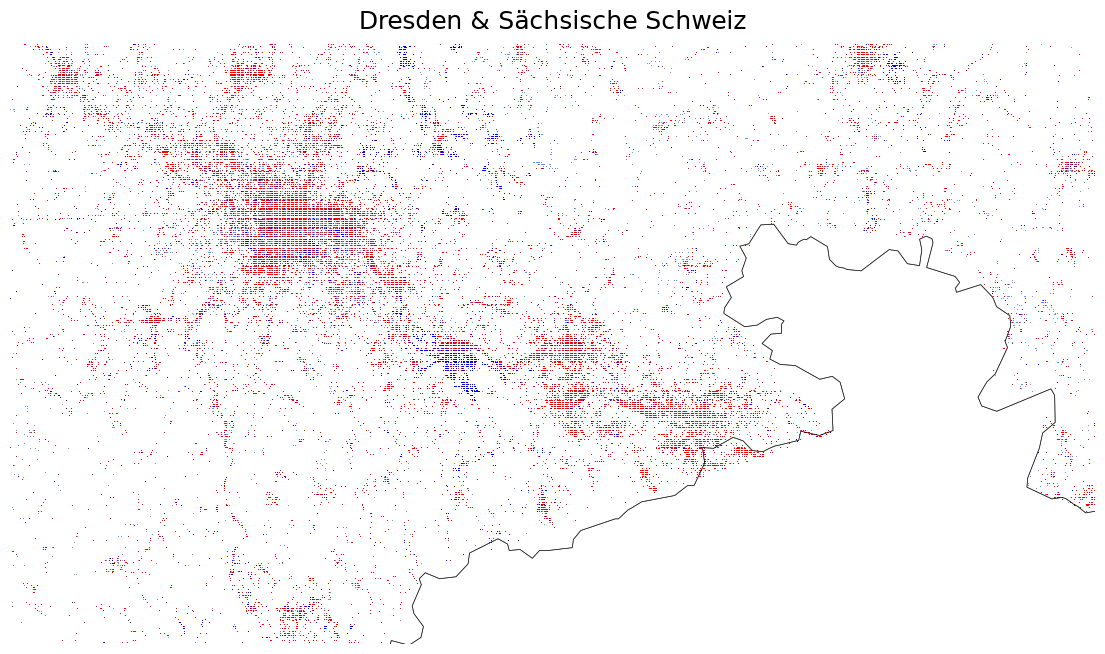

In [8]:
from modules import digitaltraces

regions_to_plot = {
    "Dresden & Sächsische Schweiz": ((13.41, 14.70), (50.74, 51.19)),
    "Baltic Coast (Rügen/Usedom)":  ((13.00, 14.56), (54.00, 54.74)),
    "Leipzig Urban Core":           ((12.20, 12.55), (51.26, 51.37))
}

name = "Dresden & Sächsische Schweiz"
bounds = regions_to_plot[name]

df_subset = digitaltraces.query_region(con, parquet_dir, bounds)
fig = digitaltraces.render_datashader_map(df=df_subset, bounds=bounds, border=nuts1_de, title=name)
plt.show()

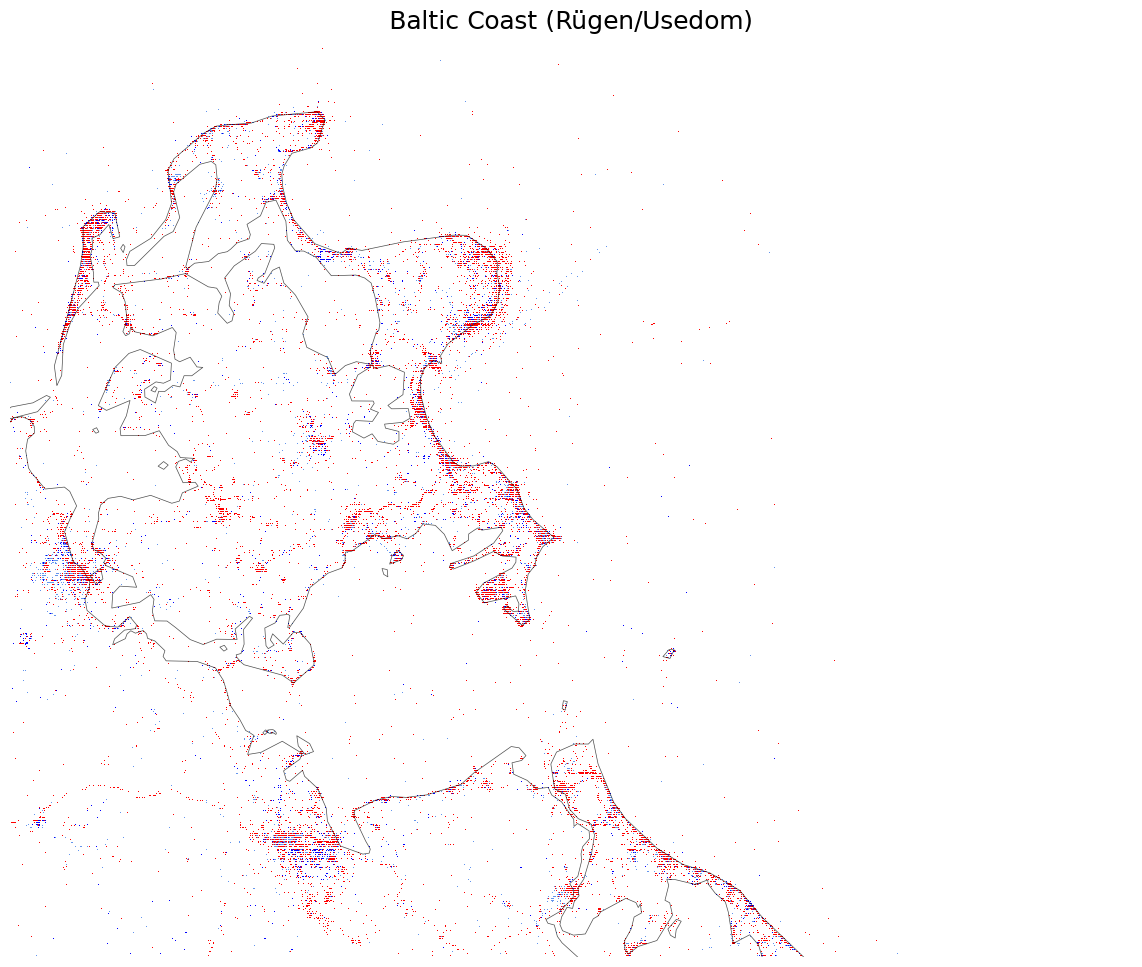

In [9]:
name = "Baltic Coast (Rügen/Usedom)"
bounds = regions_to_plot[name]

df_subset = digitaltraces.query_region(con, parquet_dir, bounds)
fig = digitaltraces.render_datashader_map(df=df_subset, bounds=bounds, border=nuts1_de, title=name)
plt.show()

By maintaining a versioned environment, we can guarantee that this output matches the original publication pixel-by-pixel. The cartographic process becomes transparent. Even though it still is and remains complex: see the documentation for the initial processing of the data [here](https://code.ad.ioer.info/digital_traces_map/).

### Limits of Replication

If you look at the maps above, you will notice the fine, dotted, grid-like pattern. This is not a rendering artifact! It is the direct consequence of the **privacy-preserving Geohash-7 snapping** that was applied to the published replication dataset {cite:p}`dunkel_replication_2025`.

Because lat-lng coordinates can be highly specific, almost to the degree of Unique IDs: To prevent the re-identification of individuals, every social media post was snapped to the center of a 153x153 meter grid cell *before* publication. At the national scale, these cells overlap enough to look like smooth density clouds. But when zooming into a region, most grid cells contain only a single, isolated data point. 

When rendered with standard browser or plot anti-aliasing, these isolated 1-pixel dots blur into the white background and disappear entirely. To make them visible here, our `digitaltraces.py` module disables image smoothing (`interpolation='nearest'`) and dynamically locks the figure size to the canvas aspect ratio.

But what happens if a local planner wants to analyze a specific urban core. For example, for Leipzig? Expand the code cell below to see what happens when we over-zoom into snapped data.

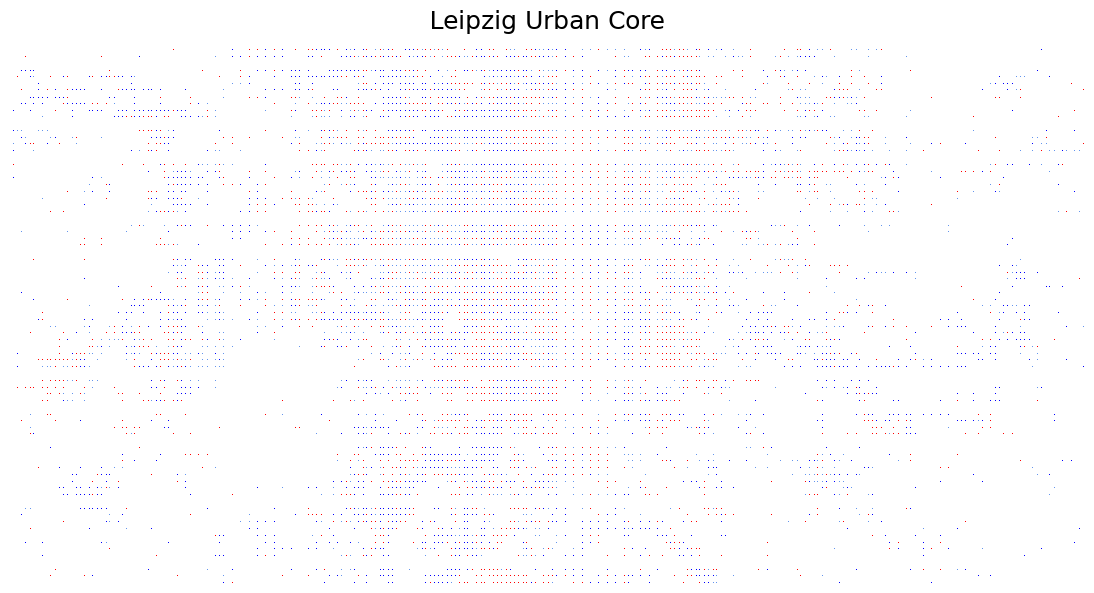

In [10]:
name = "Leipzig Urban Core"
bounds = regions_to_plot[name]

df_subset = digitaltraces.query_region(con, parquet_dir, bounds)
fig = digitaltraces.render_datashader_map(df=df_subset, bounds=bounds, border=nuts1_de, title=name)
plt.show()

At this zoom level, the data transforms into an illegible matrix. We can no longer distinguish meaningful hotspots from sparse outliers. Even a background map would be of not much help here.

This is a common trade-off in geospatial data science. Strict privacy measures limit the usefulness of raw visualizations at local scales. To extract meaningful insights for regional planning, we cannot rely on point-density alone. We must transition to advanced spatial statistics.

## 3. Beyond Replication

The source uses three labels throughout: `Local` for posts from users whose inferred home is inside Germany, `Tourist` for inferred home outside Germany, and `Unclassified` where no origin class is available. 

The following workflow finds places whose post composition differs from the complete input dataset. The input can be all of Germany, a region, or a city. The implementation details live in `modules.composition_hotspots`, this chapter concentrates on the workflow and results. We will create a hexagon-based map that indicates where we find statistically significantly more local or tourist posts. Some examples: 

|  |  |
|:--:|:--:|
| ![Dresden composition hot spots](../resources/201_digital_landscape_traces/Dresden.jpeg)<br>**Dresden** | ![Leipzig composition hot spots](../resources/201_digital_landscape_traces/Leipzig.jpeg)<br>**Leipzig** |
| ![Nordfriesland composition hot spots](../resources/201_digital_landscape_traces/Nordfriesland.jpeg)<br>**Nordfriesland** | ![Rhein-Neckar composition hot spots](../resources/201_digital_landscape_traces/Rhein-Neckar.jpeg)<br>**Rhein-Neckar** |

### 3.1 Choose the input and parameters

`DATA_SOURCE` contains the input dataset and may be a Parquet file or directory of Parquet files. This dataset (either all of Germany, a region or a city extent) is then used to create a baseline that local cells are statistically analyzed against. 

The local cells have the shape of a hexagon and can have varying radii. We use the H3 library permitting resolutions 0–15 (table below), but the released coordinates were already snapped to an approximately 153 m Geohash-7 grid. Hence a practical range here is **H3 8–10**: 8 gives broad regional smoothing, 9 is the conservative default, and 10 is the finest defensible level. Finer levels create cells smaller than the source precision without recovering detail so that the resulting map would mislead viewers.

The table below indicated the mean edge length for each hexogon resolution, following the structure of the [H3 resolution table](https://h3geo.org/docs/3.x/core-library/restable/). The values below are recalculated across every H3 cell whose centre lies inside the German NUTS-0 boundary.

| H3 resolution | Mean hexagon area in Germany | Mean edge length in Germany | H3 cells in Germany |
|---:|---:|---:|---:|
| 7 | 4.643480 km² | 1,339.07 m | 76,706 |
| 8 | 0.663358 km² | 506.12 m | 536,957 |
| 9 | 0.094765 km² | 191.30 m | 3,758,884 |
| 10 | 0.013538 km² | 72.30 m | 26,312,269 |

Depending of the level of granularity, you can pick a different level. We recommend starting with resolution 9 and moving to 8 or 7 for larger extents if needed.

In [ ]:
from modules.composition_hotspots import (
    HotspotConfig, aggregate_posts, analyze_hotspots, busiest_hotspots,
    export_hotspots, export_lonboard_map, make_lonboard_map,
    map_with_legend, to_geodataframes,
)

DATA_SOURCE = parquet_dir     # Input file, directory, or glob; all rows define the reference.
ANALYSIS_NAME = "Germany"   # Human-readable name used in tables and output filenames.
OUTPUT_BBOX = None            # Optional ((west, east), (south, north)) output crop. Applied only AFTER analysing all DATA_SOURCE rows; it never clips the input.

config = HotspotConfig(
    h3_resolution=9,            # Practical range 8–10; 9 has ~191 m mean edges in Germany.
    neighborhood_radius=1,      # Pool each cell with its six immediate neighbours.
    minimum_classified_posts=30,  # Test only pools with at least 30 Local + Tourist posts.
    # Expert configs:
    minimum_share_difference=0.10,  # Require a difference of at least 10 percentage points.
    fdr_alpha=0.05,             # Require a BY-adjusted q-value ≤ 0.05 to control false discoveries.
)

In [12]:
# Step 1: reduce millions of posts to H3 count table in DuckDB.
aggregation = aggregate_posts(
    DATA_SOURCE, reference_name=ANALYSIS_NAME, config=config, con=con
)
display(aggregation.overview().style.format({
    "input_posts": "{:,}", "h3_cells": "{:,}",
    "classified_posts": "{:,}", "tourist_posts": "{:,}",
    "local_posts": "{:,}", "unclassified_posts": "{:,}",
    "tourist_share": "{:.2%}",
    "aggregation_seconds": "{:.2f}",
}))

,reference,input_posts,h3_cells,classified_posts,tourist_posts,local_posts,unclassified_posts,tourist_share,aggregation_seconds
0,Germany,"66,632,117","846,222","44,964,828","29,194,828","15,770,000","21,667,289",64.93%,0.43


In [13]:
# Step 2: compare every seven-hexagon neighbourhood with the input-wide share.
result = analyze_hotspots(aggregation, output_bbox=OUTPUT_BBOX)
display(result.summary().style.format({
    "output_cells": "{:,}", "tested_cells": "{:,}",
    "tourist_hotspots": "{:,}", "local_hotspots": "{:,}",
    "reference_tourist_share": "{:.2%}",
    "analysis_seconds": "{:.2f}",
}))

,reference,output_cells,tested_cells,tourist_hotspots,local_hotspots,reference_tourist_share,analysis_seconds
0,Germany,"749,862","301,467","163,284","52,018",64.93%,0.63


### 3.2 What is compared?

For each H3 cell, we pool its posts with those in its six immediate neighbours (imagine a hexagon "ring" around the central hexagon) and calculate `Tourist / (Tourist + Local)`. `Unclassified` posts are retained in the outputs but excluded from this ratio. A two-sided binomial test compares the pooled Tourist share with the share across **all available input rows**. We keep only neighbourhoods with at least 30 Local + Tourist posts, a difference of at least 10 percentage points, and a [Benjamini–Yekutieli](https://doi.org/10.1214/aos/1013699998) adjusted p-value of at most 0.05.

The produced maps therefore show neighbourhoods whose post composition is significantly and substantially more `Tourist` or more `Local` than the input-wide composition—not simply places with many posts. Because we test hundreds of thousands of overlapping neighbourhoods, some small p-values would occur by chance and the tests are not independent. Benjamini–Yekutieli adjusts them into more conservative q-values so that, even with this dependence, the expected proportion of false positives among the reported hot spots is controlled at 5%.

In [14]:
# Step 3: create matching polygon/centroid files; validation runs in the module.
geodata = to_geodataframes(result)
exported = export_hotspots(geodata, OUTPUT, ANALYSIS_NAME)
print(f"Polygon output: {exported.polygon_path}")
print(f"Centroid output: {exported.centroid_path}")

Polygon output: /Users/dome/work/tud/ioer-conference-2026-haclathon/out/germany_composition_hotspots.parquet
Centroid output: /Users/dome/work/tud/ioer-conference-2026-haclathon/out/germany_composition_hotspots_centroids.parquet


### 3.3 Explore the reported hexagons

The interactive Lonboard map renders the H3 identifiers directly over the official grey [basemap.de Web Vektor](https://basemap.de/produkte-und-dienste/web-vektor/). Red marks `Tourist` hot spots and blue marks `Local` hot spots. The legend is shown above the map; the basemap's own attribution is displayed in the lower-right corner. Zoom or hover to inspect individual cells. The same map is also written to `out/index.html`; it can be opened directly or placed on a static web host, although its basemap and JavaScript libraries still require internet access.

In [20]:
# Any MapLibre style URL can replace this official basemap.de grey style.
hotspot_map = make_lonboard_map(
    result.hotspots,
    height=500,
    basemap_style="https://sgx.geodatenzentrum.de/gdz_basemapde_vektor/styles/bm_web_gry.json",
)
map_path = export_lonboard_map(
    hotspot_map, OUTPUT / "index.html", title=f"{ANALYSIS_NAME} composition hot spots"
)
print(f"Standalone map exportet to: {map_path} (this file weighs <10Mb and can be sent to colleagues or hosted online)")
map_with_legend(hotspot_map)

Standalone map exportet to: /Users/dome/work/tud/ioer-conference-2026-haclathon/out/index.html (this file weighs <10Mb and can be sent to colleagues or hosted online)


### 3.4 Inspect the busiest reported neighbourhoods

These are the top reported neighbourhoods with the most classified posts. Adjacent rows can overlap because each statistic uses a focal hexagon and its neighbours.

In [21]:
top_hotspots = busiest_hotspots(geodata.polygons, count=20)
display(top_hotspots.style.format({
    "neighborhood_classified_posts": "{:,}",
    "neighborhood_tourist_share": "{:.2%}",
    "share_difference": "{:+.2%}", "q_value": "{:.3g}",
}))

,h3_cell,neighborhood_classified_posts,neighborhood_tourist_share,share_difference,q_value,hot_spot_type
0,891f158f1abffff,"1,018,692",52.09%,-12.84%,0,Local hot spot
1,891fae72627ffff,"587,632",0.04%,-64.89%,0,Local hot spot
2,891fae72637ffff,"587,603",0.03%,-64.89%,0,Local hot spot
3,891fae72623ffff,"587,569",0.03%,-64.90%,0,Local hot spot
4,891fae7262fffff,"587,464",0.02%,-64.91%,0,Local hot spot
5,891fae72633ffff,"587,452",0.02%,-64.90%,0,Local hot spot
6,891fae7263bffff,"587,350",0.02%,-64.91%,0,Local hot spot
7,891fae7262bffff,"587,335",0.01%,-64.91%,0,Local hot spot
8,891f1d48947ffff,"367,265",75.62%,+10.69%,0,Tourist hot spot
9,891f1d48943ffff,"355,809",83.02%,+18.09%,0,Tourist hot spot


In [19]:
top_hotspot_map = make_lonboard_map(
    result.hotspots.nlargest(len(top_hotspots), "neighborhood_classified_posts"),
    height=500,
)
map_with_legend(top_hotspot_map)

## Conclusion

By starting with a massive, raw dataset, we were able to quickly reproduce a complex national map, verifying the original scientific claims. But more importantly, we adapted the workflow to solve a real-world problem for a journalist, transforming abstract spatial coordinates into a tangible story about human behavior.

None of this would be possible without robust research data management. Infrastructures like the IOER-FDZ and the FAIR principles they champion ensure that data is not merely archived, but kept alive. When we combine open data with cloud-based computational environments, we empower planners, journalists, and citizens to collaboratively shape the transformative governance of our cities and landscapes.

```{admonition} Methodological & Technical Architecture 
:class: dropdown, info

How was this built?

1. **Classification Pipeline**: Built using `dask` and `datashader` inside **Carto-Lab Docker** v1.1.0 {cite:p}`dunkel_replication_2025`.
2. **Privacy Measures**: Geohash-7 spatial snapping prevents 1:1 reverse matching with public online posts {cite:p}`dunkel_replication_2025`.
3. **Reproducibility**: Run directly in [Jupyter4NFDI](https://base4nfdi.de/projects/jupyter4nfdi) or Google Colab [8].
```

## References

```{bibliography}
:style: unsrt
:filter: docname in docnames
```